# Five Regression Python Modules That Every Data Scientist Must Know

Regression is a very important concept in statistical modelling, data science, and machine learning that helps establish a possible relationship between an independent variable (or predictor), x, with a dependent variable (or simply output) y(x) by using specific mathematical minimisation criteria. 

---

## 1. polyfit of NumPy

NumPy that stands for Numerical Python is probably the most important and efficient Python library for numerical calculations involving arrays. In addition to several operations for numerical calculations, NumPy has also a module that can perform simple linear regression and polynomial regression.

---

In [1]:
import numpy as np
x = np.array([ 56755.72171242,  44178.04737774,  40991.80813814,   8814.00098681, 43585.51198178,  13574.17183072,   6175.8760297 ,  17829.69832237, 53254.85637009,  17522.23018625,  42784.69836164,  36638.18492916, 41086.72967373,  18167.77372717,  12706.89121489,  52564.42917946, 61995.42280258,  35776.79516181,  30230.22630213,  34524.46986093, 13774.60527391,  14258.22933451, 101376.49657434,   9616.64500569, 45175.23189338,  38615.99518491,  74355.51585756,  12578.49547344, 19242.3664711 ,  16310.988409  ,  20881.76692993,   5734.63362915, 25732.01836475,  51545.48360953,  82081.59716162,  11006.2497364 , 44974.83187718,  56839.38177423])
y = np.array([7.3, 7.1, 6.9, 6.4, 7.4, 6.5, 6.3, 6.7, 7.6, 5.7, 7.6, 6.5, 7.0, 5.4, 5.6, 7.5, 7.0, 7.2, 6.0, 5.9, 5.9, 5.9, 6.9, 6.5, 7.4, 7.3, 7.6, 6.1, 5.4, 6.2, 5.9, 4.7, 6.3, 7.3, 7.5, 5.5, 6.8, 6.9])


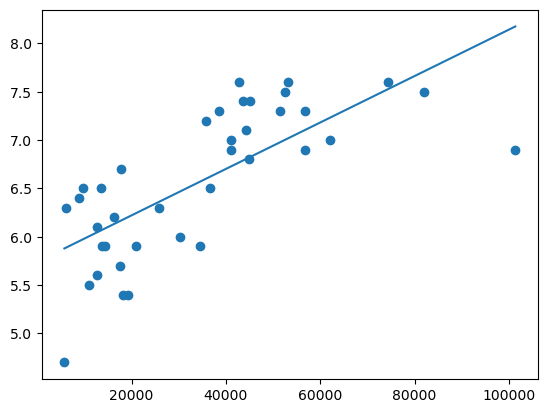

In [2]:
import matplotlib.pyplot as plt
p = np.poly1d(np.polyfit(x, y, 1))
x_line = np.linspace(np.amin(x), np.amax(x), 200)
plt.scatter(x, y)
plt.plot(x_line, p(x_line))
plt.show()

---
## 2. linregress of SciPy

SciPy is a Python library that stands for Scientific Python. It is the most important library for scientific computing that is used in academia and the scientific industry. This library contains several modules that are used for specific purposes. 

The scipy.stats() module has a submodule completely dedicated to linear regression which goes under the **syntax:** scipy.stats.linregress() and uses the least square method as a minimisation criteria.

---

In [3]:
import scipy as sp
regr_results = sp.stats.linregress(x, y)
print(regr_results)

LinregressResult(slope=np.float64(2.3996299825729513e-05), intercept=np.float64(5.741754353755326), rvalue=np.float64(0.720287195322656), pvalue=np.float64(3.4265564700646986e-07), stderr=np.float64(3.851624914535862e-06), intercept_stderr=np.float64(0.15853194959552008))


---

## 3. OLS and ols of statsmodels

The statsmodels library/module is an extension of the scipy.stats module that is mainly used for fitting a model to a given dataset. This module is probably the most complete one regarding regression in general and also linear regression in particular.

---

In [10]:
import statsmodels.api as sm

# Constant add karna zaroori hai intercept ke liye
x = sm.add_constant(x) 

# Model fit karna
lin_model = sm.OLS(y, x)
regr_results = lin_model.fit()

# Sahi tareeka results dekhne ka
print(regr_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     38.82
Date:                Tue, 05 May 2026   Prob (F-statistic):           3.43e-07
Time:                        12:59:53   Log-Likelihood:                -28.824
No. Observations:                  38   AIC:                             61.65
Df Residuals:                      36   BIC:                             64.92
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7418      0.159     36.218      0.0

---

## 4. LinearRegression of scikit-learn

scikit-learn is one of the best Python libraries for statistical/machine learning and it is adapted for fitting and making predictions. It gives the user different options for numerical calculations and statistical modelling. Its most important sub-module for linear regression is LinearRegression. It uses the least square method as minimisation criteria to find the parameters of the linear regression.

---

In [16]:
import numpy as np
from sklearn import linear_model

# 1. Pehle data ko clean NumPy array mein convert karein
x_array = np.array(x).flatten() # Isse x bilkul seedha 1D array ban jayega
y_array = np.array(y).flatten()

# 2. Ab check karein minimum length kya hai (taake mismatch na ho)
min_len = min(len(x_array), len(y_array))

# 3. Dono ko barabar length par slice karein
X_final = x_array[:min_len].reshape(-1, 1)
y_final = y_array[:min_len]

# 4. Ab fit karein
linmodel = linear_model.LinearRegression(fit_intercept=True)
linmodel.fit(X_final, y_final)

print("Model Training Successful!")
print("Coefficients:", linmodel.coef_)

Model Training Successful!
Coefficients: [-5.18708181e-06]


---

## 5. regplot of seaborn

The seaborn Python library is a very important library for visualisation of statistical results. Technically, it is not a library that can be used to calculate the regression parameters as I showed in the previous sections, but it can be used to graphically visualise the regression lines and confidence regions in a plot.

---

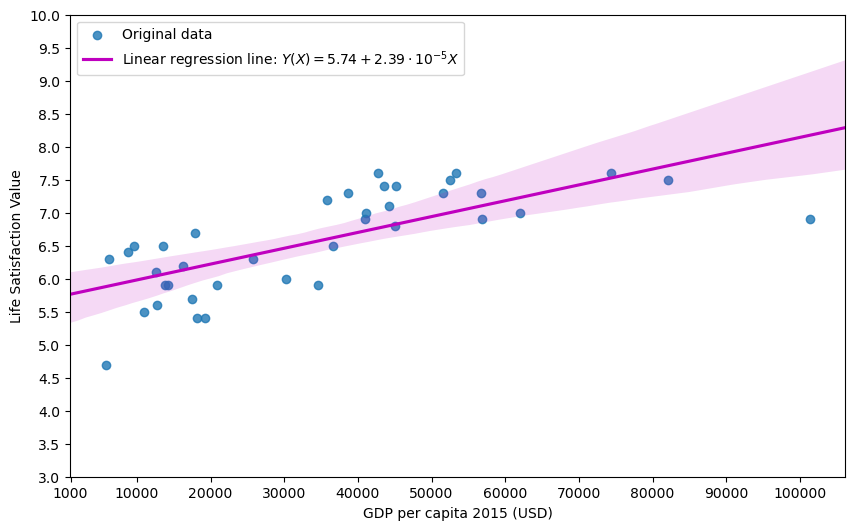

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 6))

# --- DATA CLEANING STEP ---
# Agar x statsmodels se aaya hai toh usme 2 columns honge. 
# Hum sirf aakhri column (GDP wala) uthayenge aur usay 38 samples tak limit kar denge.
x_fixed = np.array(x)
if x_fixed.ndim > 1 and x_fixed.shape[1] > 1:
    x_fixed = x_fixed[:, 1] # Dusra column uthayein (bias ke baad wala)
else:
    x_fixed = x_fixed.flatten()

# Ab dono ko 38 par lock kar dete hain taake length mismatch kabhi na aaye
common_len = min(len(x_fixed), len(y))
x_final = x_fixed[:common_len]
y_final = np.array(y)[:common_len]
# --------------------------

sns.regplot(
    x=x_final, 
    y=y_final, 
    ci=95, 
    order=1,
    line_kws={'label': r'Linear regression line: $Y(X)=5.74+2.39 \cdot 10^{-5} X$', 'color': 'm'}, 
    seed=1,
    truncate=False, 
    label="Original data"
)

ax.set_xlabel("GDP per capita 2015 (USD)")
ax.set_ylabel("Life Satisfaction Value")
ax.set_xticks([1000, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000])
ax.set_yticks(np.arange(3.0, 10.5, 0.5))
ax.legend(loc="upper left")

plt.show()